In [17]:
import numpy as np
import pandas as pd

# Load scaled feature matrix (used by Isolation Forest)
X_scaled = np.load("../data/processed/X_scaled.npy")

# Load feature names (for reference / plotting)
with open("../data/processed/feature_names.txt") as f:
    numeric_features = [line.strip() for line in f]

# Load cleaned data (for IDs, timestamps, addresses, reporting)
df = pd.read_csv("../data/processed/uniswap_v3_usdc_weth_swaps_processed.csv")

# Load Isolation Forest results
if_results = pd.read_csv("../results/isolation_forest_results.csv")



# Sanity check
assert X_scaled.shape[0] == len(if_results)
assert X_scaled.shape[1] == len(numeric_features)

print("X_scaled shape:", X_scaled.shape)
print("Features:", numeric_features)


X_scaled shape: (1000, 7)
Features: ['amount0', 'amount1', 'sqrtPriceX96', 'liquidity', 'tick', 'gasPrice', 'gasUsed']


In [18]:
#1 AE
# NORMAL data only (training)
normal_mask = if_results["isolation_forest_anomaly"] == 1
X_ae_train = X_scaled[normal_mask.values]

print("AE training shape:", X_ae_train.shape)

# ALL data (scoring / reconstruction error)
X_ae_all = X_scaled

print("AE evaluation shape:", X_ae_all.shape)




AE training shape: (950, 7)
AE evaluation shape: (1000, 7)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

# Use ONLY Isolation Forest normal transactions
normal_mask = if_results["isolation_forest_anomaly"] == 1
X_ae = X_scaled[normal_mask.values]

print("Autoencoder training data shape:", X_ae.shape)




Autoencoder training data shape: (950, 7)


In [20]:
from sklearn.model_selection import train_test_split

# Split Isolation Forest normal data into train / validation
X_train, X_val = train_test_split(
    X_ae,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)


Train shape: (855, 7)
Validation shape: (95, 7)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

input_dim = X_train.shape[1]

autoencoder = Sequential([
    Input(shape=(input_dim,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),        # bottleneck
    Dense(16, activation="relu"),
    Dense(input_dim, activation="linear")
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527 (2.06 KB)

 Trainable params: 527 (2.06 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=32,
    shuffle=True,
    verbose=1
)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5345.5225 - val_loss: 62.9214
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4937.2729 - val_loss: 57.5804
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4548.8965 - val_loss: 51.9016
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4000.3315 - val_loss: 46.4434
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3205.1499 - val_loss: 43.4674
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2262.4407 - val_loss: 42.6852
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1157.3840 - val_loss: 43.2752
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 518.6165 - val_loss: 43.6762
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 157.6909 - val_loss: 40.2919
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 64.9326 - val_loss: 37.2292
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.7697 - val_loss: 34.1303
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━

In [23]:
# Reconstruct ALL transactions
reconstructions_all = autoencoder.predict(X_scaled)

# Reconstruction error per transaction (MSE)
reconstruction_error_all = np.mean(
    np.square(X_scaled - reconstructions_all),
    axis=1
)

print("Reconstruction error summary:")
print(pd.Series(reconstruction_error_all).describe())



32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Reconstruction error summary:
count    1000.000000
mean       15.154368
std       131.447969
min         0.012431
25%         0.105970
50%         0.215404
75%         0.462203
max      2054.930651
dtype: float64


In [24]:
# Attach AE results to metadata (important)
df["ae_reconstruction_error"] = reconstruction_error_all


In [25]:
# 95th percentile threshold from AE reconstruction error
threshold = np.percentile(reconstruction_error_all, 95)

print("Autoencoder threshold (95th percentile):", threshold)

# -1 = anomaly, 1 = normal
ae_labels = np.where(
    reconstruction_error_all > threshold,
    -1,
    1
)

# Attach results to main dataframe
df["ae_anomaly"] = ae_labels

# Counts
ae_anomaly_count = (df["ae_anomaly"] == -1).sum()
ae_normal_count  = (df["ae_anomaly"] == 1).sum()

print("Autoencoder anomalies:", ae_anomaly_count)
print("Autoencoder normal   :", ae_normal_count)




Autoencoder threshold (95th percentile): 3.7662175468434604
Autoencoder anomalies: 50
Autoencoder normal   : 950


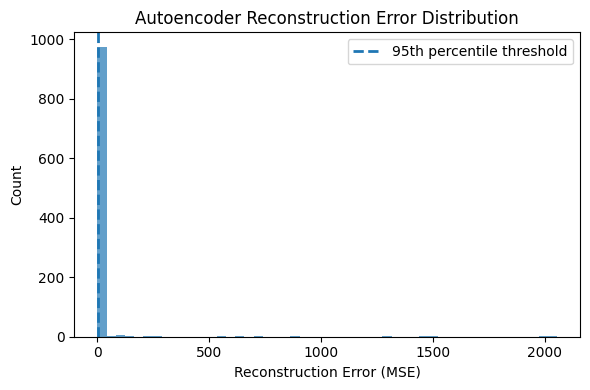

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 4))

plt.hist(
    reconstruction_error_all,
    bins=50,
    alpha=0.7
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="95th percentile threshold"
)

plt.title("Autoencoder Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

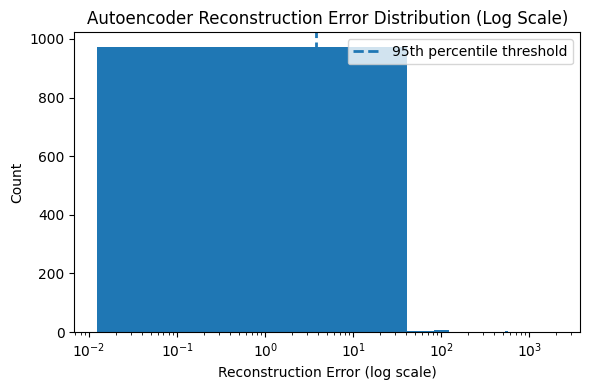

In [27]:
plt.figure(figsize=(6, 4))

plt.hist(
    reconstruction_error_all,
    bins=50
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="95th percentile threshold"
)

plt.xscale("log")
plt.xlabel("Reconstruction Error (log scale)")
plt.ylabel("Count")
plt.title("Autoencoder Reconstruction Error Distribution (Log Scale)")
plt.legend()
plt.tight_layout()
plt.show()


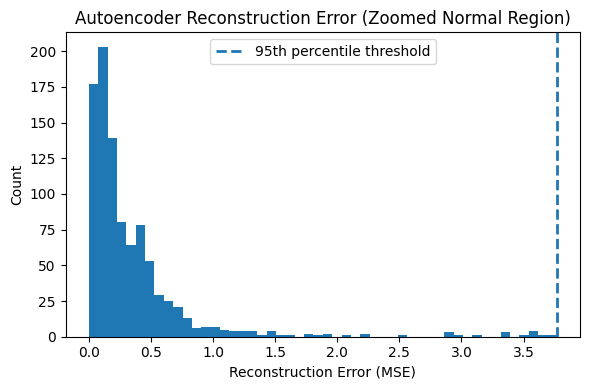

In [28]:
plt.figure(figsize=(6, 4))

plt.hist(
    reconstruction_error_all,
    bins=50,
    range=(0, threshold)
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="95th percentile threshold"
)

plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.title("Autoencoder Reconstruction Error (Zoomed Normal Region)")
plt.legend()
plt.tight_layout()
plt.show()


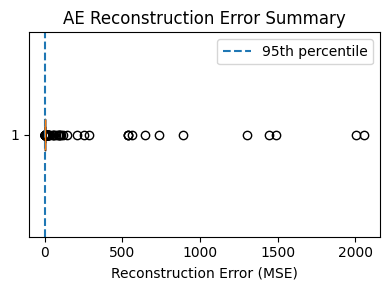

In [29]:
plt.figure(figsize=(4, 3))
plt.boxplot(reconstruction_error_all, vert=False)
plt.axvline(threshold, linestyle="--", label="95th percentile")
plt.xlabel("Reconstruction Error (MSE)")
plt.title("AE Reconstruction Error Summary")
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
ae_threshold = threshold
# Add readable label
df["ae_label"] = np.where(df["ae_anomaly"] == -1, "anomaly", "normal")

# Save AE results
ae_results = df[[
    "transactionHash",
    "ae_anomaly",
    "ae_label",
    "ae_reconstruction_error"
]].copy()

# Add threshold as metadata column
ae_results["ae_threshold"] = ae_threshold

ae_results.to_csv(
    "../results/autoencoder_results.csv",
    index=False
)

print("Autoencoder results saved.")
print(ae_results["ae_label"].value_counts())
ae_results.head()


Autoencoder results saved.
ae_label
normal     950
anomaly     50
Name: count, dtype: int64


,transactionHash,ae_anomaly,ae_label,ae_reconstruction_error,ae_threshold
0,0x8187139f2cf5e1d2b0a817f2951f0592fccc43dabf71...,1,normal,0.756243,3.766218
1,0x29ec08dc5eed0e1cd411b29c52607661155087ffa107...,1,normal,0.764599,3.766218
2,0xcf7b968094b30c7a7e1c88003e8496c621b73ef284e4...,1,normal,0.733935,3.766218
3,0x070379239598fdeaed5cf8910f87135c55783fb75778...,1,normal,0.477439,3.766218
4,0xb3bb64bb54d6465a80bfa0fe396868c08c40595b84e9...,1,normal,0.779793,3.766218
